# Assignment: Video Quality Inference

To this point in the class, you have learned various techniques for leading and analyzing packet captures of various types, generating features from those packet captures, and training and evaluating models using those features.

In this assignment, you will put all of this together, using a network traffic trace to train a model to automatically infer video quality of experience from a labeled traffic trace.

## Part 1: Warmup

The first part of this assignment builds directly on the hands-on activities but extends them slightly.

### Extract Features from the Network Traffic

Load the `netflix.pcap` file, which is a packet trace that includes network traffic. 


In [13]:
import logging
logging.getLogger("scapy.runtime").setLevel(logging.ERROR)

from netml.pparser.parser import PCAP
from netml.utils.tool import dump_data, load_data
import pandas as pd

# Load the netflix pcap and require at least 2 packets per flow
pcap = PCAP("../notebooks/data/netflix.pcap", flow_ptks_thres=2)
pcap.pcap2flows()

print(f"Number of flows: {len(pcap.flows)}")
print(f"Computed split interval: {pcap.interval:.4f} seconds")

Number of flows: 184
Computed split interval: 277.8675 seconds


In [14]:
# Look at the first few flows
for fid, pkts in pcap.flows[:5]:
    print(f"Flow: {fid}")
    print(f"  Packets: {len(pkts)}")
    print(f"  First packet: {pkts[0].summary()}")
    print()

Flow: ('192.168.43.72', '172.217.18.195', 58443, 443, 6)
  Packets: 12
  First packet: Ether / IP / TCP 192.168.43.72:58443 > 172.217.18.195:https S

Flow: ('192.168.43.72', '216.58.209.228', 58444, 443, 6)
  Packets: 67
  First packet: Ether / IP / TCP 192.168.43.72:58444 > 216.58.209.228:https S

Flow: ('192.168.43.72', '216.58.209.228', 58445, 443, 6)
  Packets: 5
  First packet: Ether / IP / TCP 192.168.43.72:58445 > 216.58.209.228:https S

Flow: ('192.168.43.72', '172.217.18.195', 58446, 443, 6)
  Packets: 5
  First packet: Ether / IP / TCP 192.168.43.72:58446 > 172.217.18.195:https S

Flow: ('192.168.43.72', '172.217.18.195', 58447, 443, 6)
  Packets: 29
  First packet: Ether / IP / TCP 192.168.43.72:58447 > 172.217.18.195:https S



### Identifying the Service Type

Use the DNS traffic to filter the packet trace for Netflix traffic.

In [15]:
from scapy.all import rdpcap, DNS, DNSRR

NF_DOMAINS = ["nflxvideo", "netflix", "nflxso", "nflxext"]

packets = rdpcap("../notebooks/data/netflix.pcap")

# Find Netflix IPs from DNS responses
netflix_ips = set()
for pkt in packets:
    if pkt.haslayer(DNS) and pkt[DNS].ancount > 0: # when pkt[DNS].ancount == 0, this is a lookup query for IP address
        for i in range(pkt[DNS].ancount):
            rr = pkt[DNS].an if i == 0 else pkt[DNS].an[i]
            if hasattr(rr, 'rrname') and hasattr(rr, 'rdata'):
                name = rr.rrname.decode() if isinstance(rr.rrname, bytes) else rr.rrname
                if any(d in name.lower() for d in NF_DOMAINS) and rr.type == 1: # if domain contains any of the key words, then it's from netflix -> add to set
                    netflix_ips.add(rr.rdata)

print(f"Found {len(netflix_ips)} Netflix IP addresses:")
for ip in sorted(netflix_ips):
    print(f"  {ip}")

# Filter flows to only those involving a Netflix IP
netflix_flows = [(fid, pkts) for fid, pkts in pcap.flows
                 if fid[0] in netflix_ips or fid[1] in netflix_ips]

print(f"\nFiltered from {len(pcap.flows)} total flows to {len(netflix_flows)} Netflix flows")

Found 15 Netflix IP addresses:
  198.38.120.130
  198.38.120.134
  198.38.120.137
  198.38.120.153
  198.38.120.162
  198.38.120.164
  198.38.120.166
  198.38.120.167
  34.252.77.54
  52.19.39.146
  52.208.128.101
  52.210.133.255
  52.210.19.176
  52.48.148.78
  52.48.8.150

Filtered from 184 total flows to 110 Netflix flows


### Generate Statistics

Generate statistics and features for the Netflix traffic flows. Use the `netml` library or any other technique that you choose to generate a set of features that you think would be good features for your model. 

In [16]:
import copy

# Create a copy so we don't modify the original pcap
netflix_pcap = copy.copy(pcap)
netflix_pcap.flows = netflix_flows

# Extract STATS features (summary statistics per flow)
netflix_pcap.flow2features("STATS", fft=False, header=False)

print(f"Feature matrix shape: {netflix_pcap.features.shape}")
print(f"(rows = Netflix flows, columns = statistical features)")

Feature matrix shape: (110, 12)
(rows = Netflix flows, columns = statistical features)


In [17]:
feature_names = ["duration", "pkts_per_sec", "bytes_per_sec", 
                 "mean_pkt_size", "std_pkt_size", "median_pkt_size",
                 "q1_pkt_size", "q3_pkt_size", "min_pkt_size", 
                 "max_pkt_size", "num_pkts", "total_bytes"]

stats_df = pd.DataFrame(netflix_pcap.features, columns=feature_names)
stats_df.head(50)

,duration,pkts_per_sec,bytes_per_sec,mean_pkt_size,std_pkt_size,median_pkt_size,q1_pkt_size,q3_pkt_size,min_pkt_size,max_pkt_size,num_pkts,total_bytes
0,14.440177,0.831015,73.683308,88.666667,48.140997,66.0,66.0,69.0,66.0,200.0,12.0,1064.0
1,14.442865,0.761622,69.099863,90.727273,49.772374,66.0,66.0,72.0,66.0,200.0,11.0,998.0
2,14.437420,0.831173,73.697377,88.666667,48.140997,66.0,66.0,69.0,66.0,200.0,12.0,1064.0
3,138.854511,1.497971,184.560082,123.206731,66.443951,66.0,66.0,200.0,54.0,200.0,208.0,25627.0
4,74.817607,0.360878,45.203263,125.259259,66.350692,66.0,66.0,200.0,54.0,200.0,27.0,3382.0
5,17.894865,0.726465,63.817190,87.846154,46.815261,66.0,66.0,78.0,54.0,200.0,13.0,1142.0
6,430.839378,0.510631,80.621693,157.886364,62.623919,66.0,200.0,200.0,54.0,200.0,220.0,34735.0
7,17.891358,0.558929,50.750759,90.800000,53.022259,66.0,66.0,75.0,54.0,200.0,10.0,908.0
8,17.886625,0.614985,54.454097,88.545455,51.054986,66.0,66.0,72.0,54.0,200.0,11.0,974.0
9,70.155289,0.228065,24.488531,107.375000,61.541526,66.0,66.0,194.0,54.0,200.0,16.0,1718.0


I chose STATS since the main thing that determines video quality is how much data is being sent per second which can be seen with features like bytes/sec and packets/sec. I also considered time-series approaches like SAMP or IAT, but STATS always gives a fixed 12 features per flow no matter how long it lasts, which keeps things simple and avoids issues with padding or truncating flows to the same length.

### Inferring Segment downloads

In addition to the features that you could generate using the `netml` library or similar, add to your feature vector a "segment downloads rate" feature, which indicates the number of video segments downloaded for a given time window.

Note: If you are using the `netml` library, generating features with `SAMP` style options may be useful, as this option gives you time windows, and you can then simply add the segment download rate to that existing dataframe.

In [18]:
import numpy as np

def count_segments(pkts):
    """Count video segments by detecting bursts separated by zero-payload packets."""
    segments = 0
    in_burst = False
    for pkt in pkts:
        payload_len = len(pkt) - 54
        if payload_len > 0:
            if not in_burst:
                segments += 1
                in_burst = True
        else:
            in_burst = False
    return segments

# Compute segment count and rate for each Netflix flow
seg_counts = []
seg_rates = []
for fid, pkts in netflix_flows:
    seg_count = count_segments(pkts)
    duration = float(pkts[-1].time - pkts[0].time)
    rate = seg_count / duration if duration > 0 else 0
    seg_counts.append(seg_count)
    seg_rates.append(rate)

# Add as new columns to our feature DataFrame
stats_df["seg_count"] = seg_counts
stats_df["seg_download_rate"] = seg_rates
print(f"Added segment count and download rate features")
stats_df[["duration", "bytes_per_sec", "seg_count", "seg_download_rate"]].head(10)

Added segment count and download rate features


,duration,bytes_per_sec,seg_count,seg_download_rate
0,14.440177,73.683308,1,0.069251
1,14.442865,69.099863,1,0.069238
2,14.437420,73.697377,1,0.069264
3,138.854511,184.560082,2,0.014404
4,74.817607,45.203263,2,0.026732
5,17.894865,63.817190,1,0.055882
6,430.839378,80.621693,5,0.011605
7,17.891358,50.750759,1,0.055893
8,17.886625,54.454097,1,0.055908
9,70.155289,24.488531,2,0.028508


## Part 2: Video Quality Inference

You will now load the complete video dataset from a previous study to train and test models based on these features to automatically infer the quality of a streaming video flow.

For this part of the assignment, you will need two pickle files. They are hosted in the course data repository on GitHub, [noise-courses/data](https://github.com/noise-courses/data), in the `video-qoe/` directory. Download them by running the code below:

```
!wget https://raw.githubusercontent.com/noise-courses/data/main/video-qoe/netflix_session.pkl
!wget https://raw.githubusercontent.com/noise-courses/data/main/video-qoe/video_dataset.pkl.xz
!xz -d video_dataset.pkl.xz
```

The dataset is stored xz-compressed in the repository (61 MB compressed, about 265 MB uncompressed), so the last line decompresses it. If `xz` is not available on your system, you can decompress it in Python instead:

```python
import lzma, shutil
with lzma.open('video_dataset.pkl.xz') as f_in, open('video_dataset.pkl', 'wb') as f_out:
    shutil.copyfileobj(f_in, f_out)
```

A smaller Netflix-only dataset (`netflix_dataset.pkl.xz`, 52,279 samples with 251 features) is available in the same directory and may be used instead of the multi-service `video_dataset.pkl` (204,713 samples with 170 features).

**Backup (Google Drive):** If GitHub is unavailable, the Netflix-only dataset is also mirrored on Google Drive:

```
!gdown 'https://drive.google.com/uc?id=1iI1tos08p9FJBI-ADR9b_iFObWRwXANX' -O netflix_dataset.pkl
```

Note: the Google Drive links that previously appeared here (file IDs `1N-Cf4dJ3fpak_AWgO05Fopq_XPYLVqdS` and `1PHvEID7My6VZXZveCpQYy3lMo9RvMNTI`) no longer work.

### Load the File

Load the video dataset pickle file.

In [20]:
import pickle

with open("video_dataset.pkl", "rb") as f:
    video_df = pickle.load(f, encoding="latin1")

print(f"Shape: {video_df.shape}")
print(f"\nColumns:\n{video_df.columns.tolist()}")
video_df.head()

Shape: (204713, 170)

Columns:
['L7_10_avg_chunksize', 'L7_10_chunksizes_50', 'L7_10_chunksizes_75', 'L7_10_chunksizes_85', 'L7_10_chunksizes_90', 'L7_10_max_chunksize', 'L7_10_min_chunksize', 'L7_10_std_chunksize', 'absolute_timestamp', 'L7_all_prev_down_chunk_iat_50', 'L7_all_prev_down_chunk_iat_75', 'L7_all_prev_down_chunk_iat_85', 'L7_all_prev_down_chunk_iat_90', 'L7_all_prev_down_chunk_iat_avg', 'L7_all_prev_down_chunk_iat_max', 'L7_all_prev_down_chunk_iat_min', 'L7_all_prev_down_chunk_iat_std', 'L7_all_prev_up_chunk_iat_50', 'L7_all_prev_up_chunk_iat_75', 'L7_all_prev_up_chunk_iat_85', 'L7_all_prev_up_chunk_iat_90', 'L7_all_prev_up_chunk_iat_avg', 'L7_all_prev_up_chunk_iat_max', 'L7_all_prev_up_chunk_iat_min', 'L7_all_prev_up_chunk_iat_std', 'L7_allprev_avg_chunksize', 'L7_allprev_chunksizes_50', 'L7_allprev_chunksizes_75', 'L7_allprev_chunksizes_85', 'L7_allprev_chunksizes_90', 'L7_allprev_max_chunksize', 'L7_allprev_min_chunksize', 'L7_allprev_std_chunksize', 'L7_cumsum_chunksi

,L7_10_avg_chunksize,L7_10_chunksizes_50,L7_10_chunksizes_75,L7_10_chunksizes_85,L7_10_chunksizes_90,L7_10_max_chunksize,L7_10_min_chunksize,L7_10_std_chunksize,absolute_timestamp,L7_all_prev_down_chunk_iat_50,...,L4_userStdRTT,L4_userStdRetransmit,L4_userStdRwnd,L4_userStrBytesInFlight,L4_userSynFlags,L4_userTwoRetransmit,L4_userUrgFlags,L4_userXRetransmit,L4_userZeroRetransmit,service
0,148947.1,43473.0,185098.0,361832.3,461040.2,539882,4380,185126.042201,1.548881e+09,161.5,...,19684.624818,57.462837,985.136457,0,4,0.0,0,0.108730,0.557937,netflix
1,91984.2,101882.0,122323.0,159843.4,181011.8,196778,24498,62449.107359,1.548881e+09,361.0,...,8183.942278,71.011784,310.123152,0,1,0.0,0,0.116865,0.549802,netflix
2,147725.0,111373.0,224157.0,286280.0,325845.8,396800,24498,134268.559725,1.548881e+09,337.0,...,7087.849223,85.198800,149.669427,0,0,0.0,0,0.126852,0.539815,netflix
3,246420.6,297522.0,330737.5,361030.7,378404.0,396800,24498,127394.372454,1.548881e+09,399.0,...,56963.445789,109.397055,14006.713648,0,1,0.0,0,0.186111,0.480556,netflix
4,336681.0,354461.0,399719.5,409866.3,414060.0,438000,198238,79844.367998,1.548881e+09,414.0,...,10988.579443,122.132897,13261.305817,0,0,0.0,0,0.194444,0.472222,netflix


### Clean the File

1. The dataset contains video resolutions that are not valid. Remove entries in the dataset that do not contain a valid video resolution. Valid resolutions are 240, 360, 480, 720, 1080.

In [22]:
# Check what resolution values exist
print("Before cleaning:")
print(video_df["resolution"].value_counts().sort_index())

# Remove invalid resolutions
valid_resolutions = [240, 360, 480, 720, 1080]
video_df = video_df[video_df["resolution"].isin(valid_resolutions)]

print(f"\nAfter removing invalid resolutions: {video_df.shape}")
print(video_df["resolution"].value_counts().sort_index())

Before cleaning:
resolution
0.0        4650
240.0     45538
360.0     31713
480.0     73056
720.0     37986
1080.0    11770
Name: count, dtype: int64

After removing invalid resolutions: (200063, 170)
resolution
240.0     45538
360.0     31713
480.0     73056
720.0     37986
1080.0    11770
Name: count, dtype: int64


2. The file also contains columns that are unnecessary (in fact, unhelpful!) for performing predictions. Identify those columns, and remove them.

In [23]:
cols_to_drop = ["resolution", "home_id", "session_id", "video_id", 
                "index", "absolute_timestamp", "service"]
video_df_clean = video_df.drop(columns=cols_to_drop)
print(f"Dropped {len(cols_to_drop)} columns: {cols_to_drop}")
print(f"Remaining shape: {video_df_clean.shape}")

Dropped 7 columns: ['resolution', 'home_id', 'session_id', 'video_id', 'index', 'absolute_timestamp', 'service']
Remaining shape: (200063, 163)


**Briefly explain why you removed those columns.**

I removed columns that are identifiers or metadata rather than actual traffic features. Things like `home_id`, `session_id`, and `video_id` would let the model memorize which household or video had which resolution instead of learning from the traffic patterns, so it wouldn't generalize to new data. `absolute_timestamp` is just when the data was collected, `index` is a row number, and `service` is the streaming platform name and none of these provide actual info for network traffic so I removed them as well. I also pulled out `resolution` since that's the label I'm trying to predict.

### Prepare Your Data

Prepare your data matrix, determine your features and labels, and perform a train-test split on your data.

In [25]:
from sklearn.model_selection import train_test_split

# Features and labels
X = video_df_clean
y = video_df["resolution"]

# 80/20 split, stratified so each resolution is proportionally represented
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training set: {X_train.shape}")
print(f"Test set:     {X_test.shape}")
print(f"\nLabel distribution in training set:")
print(y_train.value_counts().sort_index())

Training set: (160050, 163)
Test set:     (40013, 163)

Label distribution in training set:
resolution
240.0     36430
360.0     25370
480.0     58445
720.0     30389
1080.0     9416
Name: count, dtype: int64


### Train and Tune Your Model

1. Select a model of your choice.
2. Train the model using your training data.

In [26]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

train_acc = rf.score(X_train, y_train)
test_acc = rf.score(X_test, y_test)
print(f"Training accuracy: {train_acc:.4f}")
print(f"Test accuracy:     {test_acc:.4f}")

Training accuracy: 1.0000
Test accuracy:     0.9535


### Tune Your Model

Perform hyperparameter tuning to find optimal parameters for your model.

In [27]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [10, 20, None],
    "min_samples_leaf": [1, 5, 10]
}

grid_search = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid, cv=3, scoring="accuracy", n_jobs=-1, verbose=1)

grid_search.fit(X_train, y_train)

print(f"\nBest parameters: {grid_search.best_params_}")
print(f"Best CV accuracy: {grid_search.best_score_:.4f}")

Fitting 3 folds for each of 18 candidates, totalling 54 fits


/Users/clarisse/Library/Python/3.11/lib/python/site-packages/joblib/externals/loky/process_executor.py:752: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(



Best parameters: {'max_depth': None, 'min_samples_leaf': 1, 'n_estimators': 200}
Best CV accuracy: 0.9500


### Evaluate Your Model

Evaluate your model accuracy according to the following metrics:

1. Accuracy
2. F1 Score
3. Confusion Matrix
4. ROC/AUC

Accuracy: 0.9539
F1 Score (weighted): 0.9539


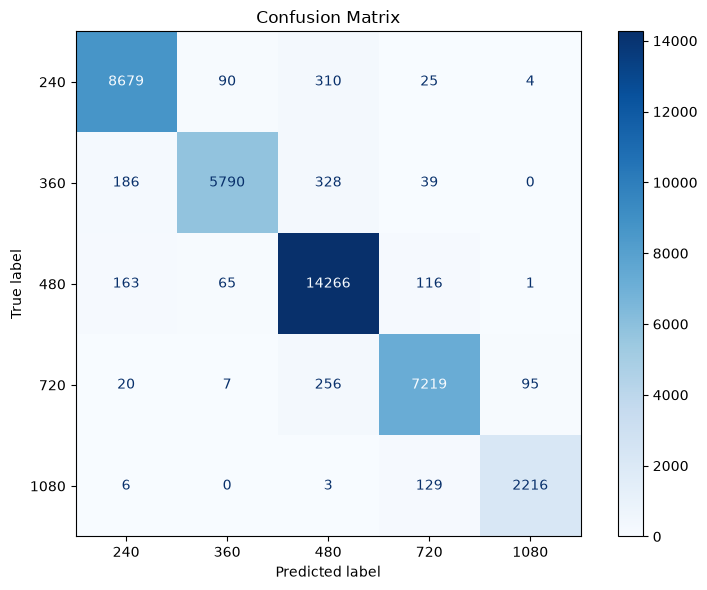

ROC AUC (weighted, one-vs-rest): 0.9970


In [28]:
from sklearn.metrics import (accuracy_score, f1_score, confusion_matrix, 
                             ConfusionMatrixDisplay, roc_auc_score)
import matplotlib.pyplot as plt

# Use the best model from grid search
best_rf = grid_search.best_estimator_
y_pred = best_rf.predict(X_test)

# 1. Accuracy
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")

# 2. F1 Score (weighted, since classes are imbalanced)
print(f"F1 Score (weighted): {f1_score(y_test, y_pred, average='weighted'):.4f}")

# 3. Confusion Matrix
fig, ax = plt.subplots(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred, labels=[240, 360, 480, 720, 1080])
disp = ConfusionMatrixDisplay(cm, display_labels=[240, 360, 480, 720, 1080])
disp.plot(ax=ax, cmap="Blues")
ax.set_title("Confusion Matrix")
plt.tight_layout()
plt.show()

# 4. ROC/AUC (one-vs-rest, using predicted probabilities)
y_prob = best_rf.predict_proba(X_test)
roc_auc = roc_auc_score(y_test, y_prob, multi_class="ovr", average="weighted")
print(f"ROC AUC (weighted, one-vs-rest): {roc_auc:.4f}")

## Part 3: Predict the Ongoing Resolution of a Real Netflix Session

Now that you have your model, it's time to put it in practice!

Use a preprocessed Netflix video session to infer **and plot** the resolution at 10-second time intervals.

The session file the assignment points to is corrupt, so I construct an equivalent held-out session out of `video_dataset.pkl` instead. To be sure the model has genuinely never seen it, I re-split the data by `session_id` rather than by row. The write-up at the end explains both choices and what they cost.

In [39]:
from sklearn.model_selection import GroupShuffleSplit

# Split by session, not by row, so whole sessions land entirely in train or test.
train_idx, held_idx = next(
    GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
    .split(X, y, groups=video_df["session_id"]))

session_rf = RandomForestClassifier(**grid_search.best_params_, random_state=42, n_jobs=-1)
session_rf.fit(X.iloc[train_idx], y.iloc[train_idx])

held = video_df.iloc[held_idx]
print(f"Trained on {video_df['session_id'].iloc[train_idx].nunique()} sessions; "
      f"{held['session_id'].nunique()} sessions held out entirely.")
print(f"Accuracy across all held-out sessions: "
      f"{session_rf.score(X.iloc[held_idx], y.iloc[held_idx]):.4f}")

Trained on 3196 sessions; 800 sessions held out entirely.
Accuracy across all held-out sessions: 0.9074


In [40]:
def n_switches(res):
    """Number of times the resolution changes over a session."""
    return int((res.diff() != 0).sum() - 1)

# Score every held-out Netflix session so the one I plot can be chosen by a stated
# rule instead of by eye.
held = held.assign(ok=(session_rf.predict(X.iloc[held_idx]) == y.iloc[held_idx].to_numpy()))
summary = (held[held["service"] == "netflix"].sort_values("relative_timestamp")
           .groupby("session_id")
           .agg(n=("ok", "size"), acc=("ok", "mean"), switches=("resolution", n_switches)))
summary = summary[summary["n"] >= 55]

print(f"{len(summary)} held-out Netflix sessions with at least 55 intervals\n")
print(summary.groupby(pd.cut(summary["switches"], [-1, 0, 2, 5, 100],
                             labels=["0", "1-2", "3-5", "6+"]), observed=True)
             .agg(sessions=("acc", "size"), median_acc=("acc", "median")).round(3))

# Flat sessions make a plot that a constant guess scores 100% on; the switchiest
# sessions are the hardest. Take the median-accuracy session among those in between.
varied = summary[summary["switches"].between(2, 5)].sort_values("acc")
sid = varied.index[len(varied) // 2]
session = held[held["session_id"] == sid].sort_values("relative_timestamp")

74 held-out Netflix sessions with at least 55 intervals

          sessions  median_acc
switches                      
0               40       1.000
1-2             20       0.966
3-5              9       0.847
6+               5       0.729


Session c8735b41 | 59 intervals | 4 switches
Accuracy on this session:          0.8644
Always-guess-most-common baseline: 0.7288


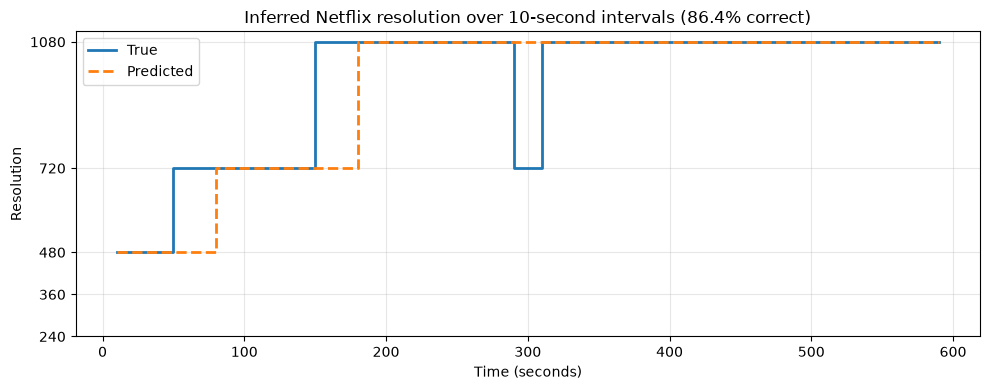

In [41]:
y_true = session["resolution"].astype(int).to_numpy()
y_pred = session_rf.predict(session[X.columns]).astype(int)
t = session["relative_timestamp"].to_numpy()

acc = (y_pred == y_true).mean()
baseline = pd.Series(y_true).value_counts(normalize=True).iloc[0]

print(f"Session {sid[:8]} | {len(session)} intervals | "
      f"{n_switches(session['resolution'])} switches")
print(f"Accuracy on this session:          {acc:.4f}")
print(f"Always-guess-most-common baseline: {baseline:.4f}")

plt.figure(figsize=(10, 4))
plt.step(t, y_true, where="post", label="True", linewidth=2)
plt.step(t, y_pred, where="post", label="Predicted", linewidth=2, linestyle="--")
plt.yticks([240, 360, 480, 720, 1080])
plt.xlabel("Time (seconds)")
plt.ylabel("Resolution")
plt.title(f"Inferred Netflix resolution over 10-second intervals ({acc:.1%} correct)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

The `netflix_session.pkl` file the instructions point to is broken. It's 1,652 bytes and opens as a Google "Error 404" page instead of a pickle, so `pd.read_pickle` fails with `invalid load key, '<'`. I built an equivalent session out of `video_dataset.pkl` instead, which is already split into 10-second intervals. My Part 2 split shuffles individual rows, so one session's intervals land on both sides of it, and since a lot of the features are cumulative over the session (`L7_allprev_*`, `L7_cumsum_chunksizes`), interval 30 looks nearly identical to interval 29. To avoid this I re-split with `GroupShuffleSplit` on `session_id`, which keeps whole sessions together and guarantees the session I plot shares no intervals with the training data. For the plot I needed a session that actually changes quality, since 40 of the 74 held-out Netflix sessions never switch at all and a flat one gives a graph that a constant guess scores 100% on. The busiest sessions are also the hardest ones though, so I took the median by accuracy among the sessions with 2 to 5 switches and printed the full table above so the choice is visible instead of cherry-picked.